## Introduction

Video Link: https://drive.google.com/file/d/1xhzY7DBDNoJKDTj_XKdoPW7hr9Skr2-6/view?usp=sharing 

This report addresses the problem of efficient data storage and querying in a lightweight DBMS setting, where linear scan approaches become slow as the number of records grows.

The proposed solution is a **B+ Tree-based DBMS** that organizes keys in a balanced multi-level index. This structure reduces lookup path length and supports scalable insert, search, update, delete, and range-query operations. The B+ Tree also links leaf nodes in sorted order, making sequential and range access efficient.

## Implementation

The B+ Tree DBMS is implemented around internal and leaf node structures with standard balancing rules.

- **Search**: Traverses internal nodes by key separators until the target leaf is reached, then performs local key lookup in the leaf.
- **Insertion**: Inserts into the target leaf; if a node overflows, it is split and a separator key is propagated upward. Root split creates a new root when required.
- **Deletion**: Removes the target key from a leaf/internal path, then rebalances with sibling borrow or merge when underflow occurs.
- **Update**: Locates the key via B+ Tree search path and replaces its associated value in place.
- **Range Query**: Finds the start key leaf, then scans forward using linked leaf pointers to collect keys in the interval efficiently.
- **Visualization Support**: Graphviz is used to render internal/leaf hierarchy, parent-child edges, and leaf-level linked-list connections for interpretability.

## B+ Tree vs Brute Force Performance Analysis

This notebook presents a **systematic and detailed** performance comparison between:
- `BPlusTree` (indexed structure)
- `BruteForceDB` (linear scan baseline)

We evaluate:
1. Insertion
2. Exact search
3. Deletion
4. Update
5. Range query
6. Mixed random workload
7. Memory usage

For each operation, we test **varying input sizes** and **special-case input patterns**, then visualize results with clean plots and summary tables.

## Theoretical Time Complexity

Let $n$ be number of records and $k$ be number of results returned by a range query.

| Operation | B+ Tree (Expected) | Brute Force (Expected) |
|---|---:|---:|
| Insert | $O(\log n)$ | $O(n)$ (scan to replace existing key, then append) |
| Exact Search | $O(\log n)$ | $O(n)$ |
| Delete | $O(\log n)$ | $O(n)$ |
| Update | $O(\log n)$ | $O(n)$ |
| Range Query | $O(\log n + k)$ | $O(n)$ |

### Special-case patterns tested
- Random unique keys
- Ascending keys
- Descending keys
- Clustered keys (narrow key band)
- Search: existing / missing / mixed
- Deletion order: ascending / descending / random
- Range width: narrow / medium / wide

These patterns help reveal behavior beyond average random inputs.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from performance import (
    benchmark_insertion,
    benchmark_search,
    benchmark_deletion,
    benchmark_update,
    benchmark_range_query,
    benchmark_mixed_workload,
    benchmark_memory,
    plot_operation_grid,
    show_speedup_table,
)

## 1) Insertion Analysis

This section compares insertion performance across increasing dataset sizes and input patterns:
- random
- ascending
- descending
- clustered

Expected trend: B+ Tree should scale better than brute force as $n$ grows.

,operation,structure,case,size,time_ms_mean,time_ms_std
0,insert,B+ Tree,ascending,500,0.654100,0.052472
1,insert,B+ Tree,clustered,500,0.552367,0.051786
2,insert,B+ Tree,descending,500,0.566200,0.012117
3,insert,B+ Tree,random,500,0.593667,0.051895
4,insert,Brute Force,ascending,500,5.939467,0.248840
5,insert,Brute Force,clustered,500,6.311400,0.051975
6,insert,Brute Force,descending,500,6.533700,1.163174
7,insert,Brute Force,random,500,6.622900,1.491953


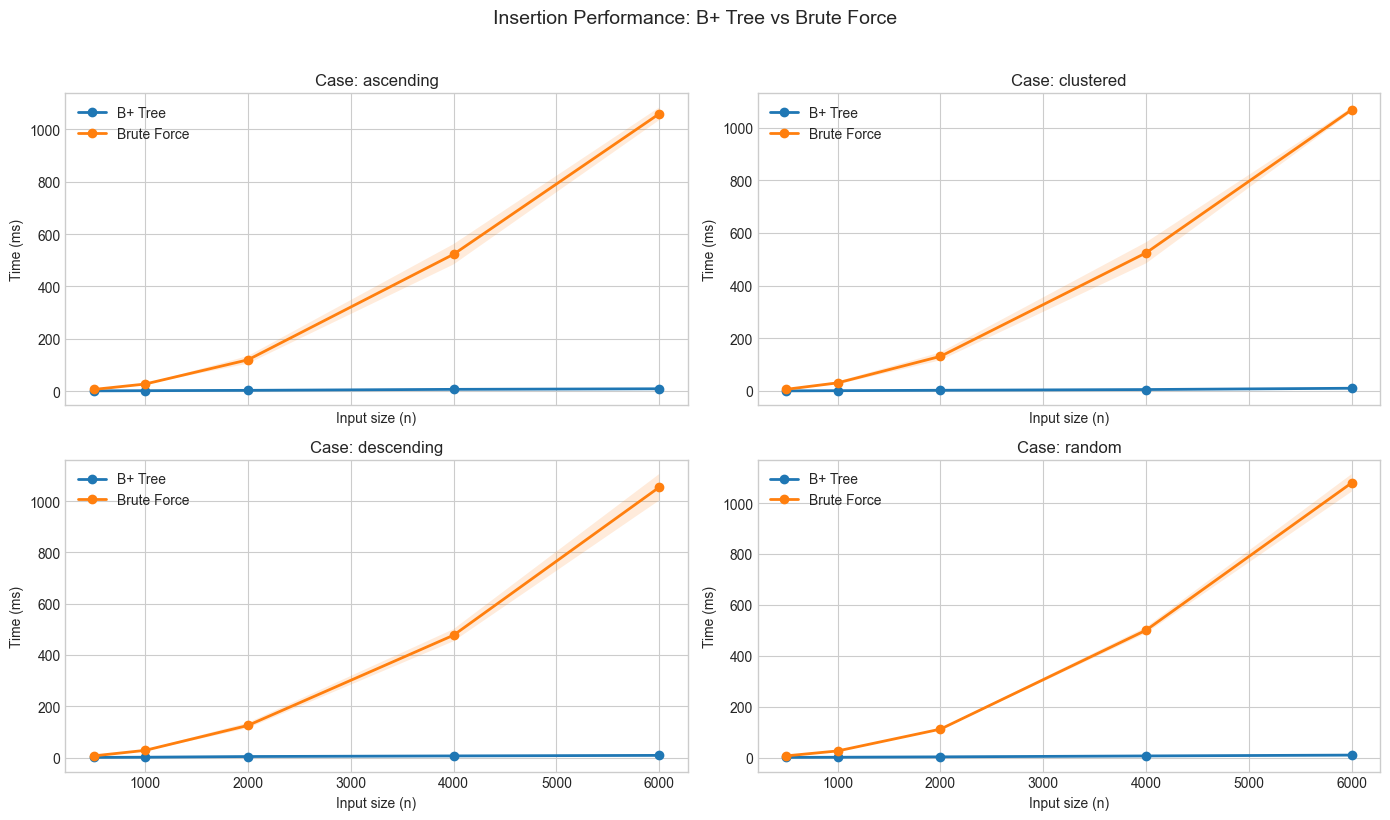


Speedup summary for Insertion:


structure,size,case,B+ Tree,Brute Force,speedup_(Brute/B+)
0,500,ascending,0.654,5.939,9.080
1,500,clustered,0.552,6.311,11.426
2,500,descending,0.566,6.534,11.540
3,500,random,0.594,6.623,11.156
4,1000,ascending,1.265,26.593,21.023
5,1000,clustered,1.185,30.768,25.965
6,1000,descending,1.342,28.034,20.892
7,1000,random,1.204,25.980,21.576
8,2000,ascending,2.519,119.229,47.332
9,2000,clustered,2.698,131.384,48.703


In [2]:
insert_df = benchmark_insertion()
display(insert_df.head(8))
plot_operation_grid(insert_df, "Insertion Performance: B+ Tree vs Brute Force")
show_speedup_table(insert_df, "Insertion")

## 2) Exact Search Analysis

Cases:
- existing keys
- missing keys
- mixed existing + missing

Expected trend: B+ Tree search should follow near $O(\log n)$ behavior, while brute force is near $O(n)$.

,operation,structure,case,size,time_ms_mean,time_ms_std
0,search,B+ Tree,existing,500,0.291300,0.026785
1,search,B+ Tree,missing,500,0.206533,0.001401
2,search,B+ Tree,mixed,500,0.326767,0.044436
3,search,Brute Force,existing,500,4.193467,0.675214
4,search,Brute Force,missing,500,7.127600,0.197314
5,search,Brute Force,mixed,500,5.466333,0.102278


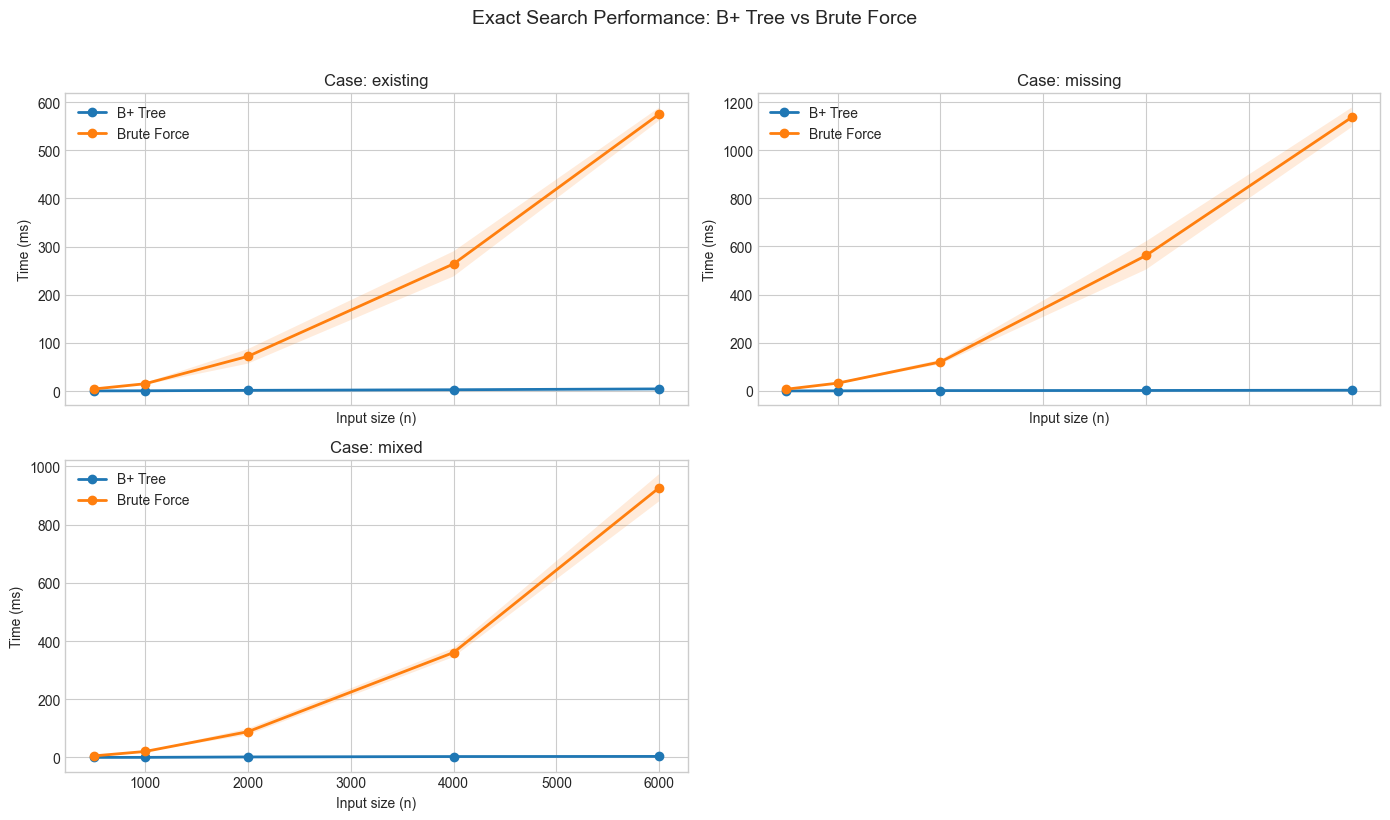


Speedup summary for Search:


structure,size,case,B+ Tree,Brute Force,speedup_(Brute/B+)
0,500,existing,0.291,4.193,14.396
1,500,missing,0.207,7.128,34.511
2,500,mixed,0.327,5.466,16.729
3,1000,existing,0.511,15.087,29.496
4,1000,missing,0.384,32.358,84.229
5,1000,mixed,0.477,20.684,43.352
6,2000,existing,1.388,71.986,51.869
7,2000,missing,1.475,120.500,81.688
8,2000,mixed,1.901,88.615,46.617
9,4000,existing,2.647,264.014,99.726


In [3]:
search_df = benchmark_search()
display(search_df.head(6))
plot_operation_grid(search_df, "Exact Search Performance: B+ Tree vs Brute Force")
show_speedup_table(search_df, "Search")

## 3) Deletion Analysis

Deletion orders tested:
- ascending delete order
- descending delete order
- random delete order

Expected trend: B+ Tree handles deletes with rebalance/merge overhead, but should still scale better than full linear scans.

,operation,structure,case,size,time_ms_mean,time_ms_std
0,delete,B+ Tree,ascending,500,0.528400,0.032306
1,delete,B+ Tree,descending,500,1.100633,0.185379
2,delete,B+ Tree,random,500,0.836733,0.023149
3,delete,Brute Force,ascending,500,3.142567,0.424777
4,delete,Brute Force,descending,500,2.986900,0.085168
5,delete,Brute Force,random,500,3.019633,0.338322


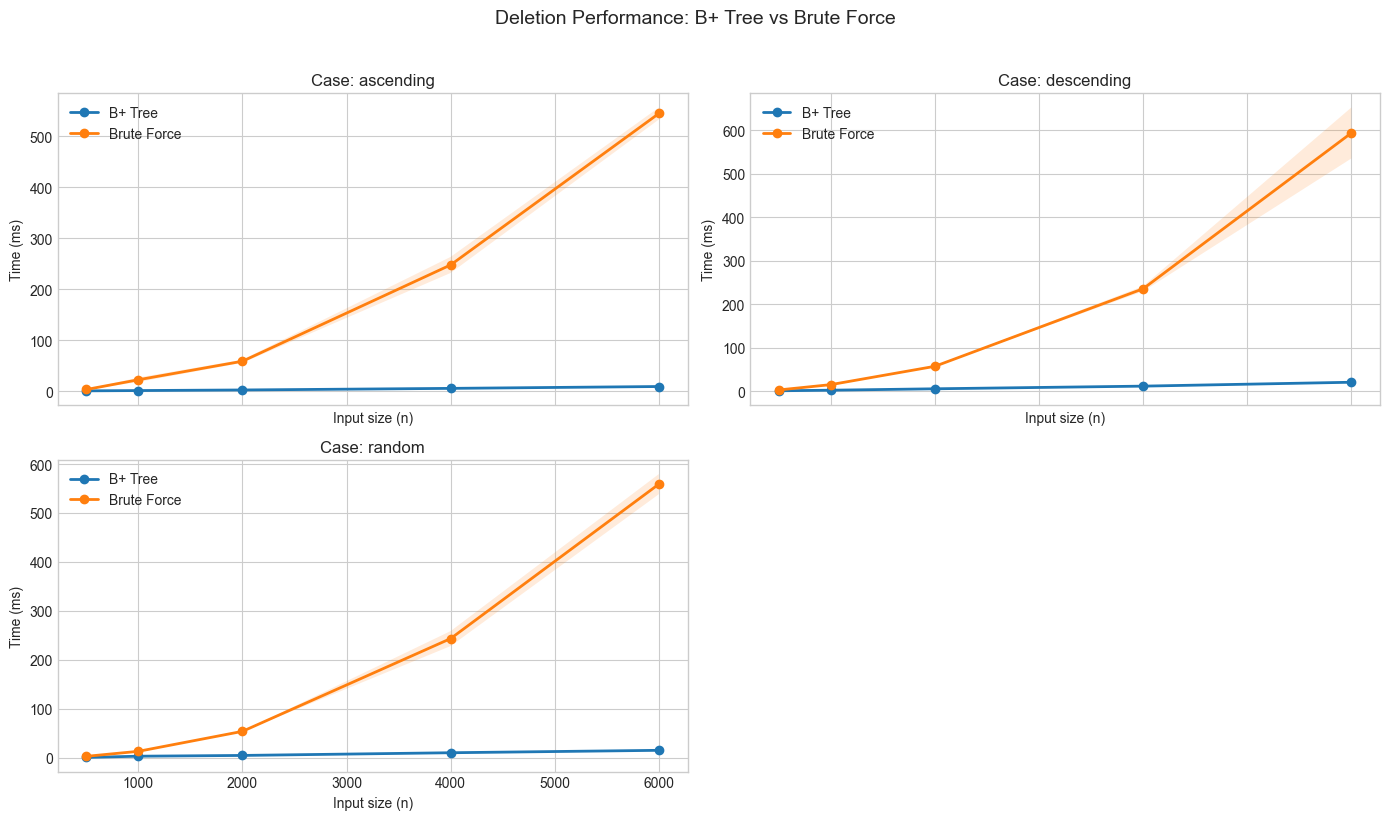


Speedup summary for Deletion:


structure,size,case,B+ Tree,Brute Force,speedup_(Brute/B+)
0,500,ascending,0.528,3.143,5.947
1,500,descending,1.101,2.987,2.714
2,500,random,0.837,3.020,3.609
3,1000,ascending,1.072,22.234,20.746
4,1000,descending,2.383,15.203,6.379
5,1000,random,3.273,13.251,4.049
6,2000,ascending,2.212,58.602,26.487
7,2000,descending,5.640,57.325,10.164
8,2000,random,4.852,54.035,11.138
9,4000,ascending,5.342,247.611,46.352


In [4]:
delete_df = benchmark_deletion()
display(delete_df.head(6))
plot_operation_grid(delete_df, "Deletion Performance: B+ Tree vs Brute Force")
show_speedup_table(delete_df, "Deletion")

## 4) Update Analysis

Updates are tested over entire keysets with:
- random update order
- ascending update order

Expected trend: update follows the same lookup complexity pattern as search + overwrite.

,operation,structure,case,size,time_ms_mean,time_ms_std
0,update,B+ Tree,ascending,500,0.379800,0.067708
1,update,B+ Tree,random,500,0.336833,0.013984
2,update,Brute Force,ascending,500,6.287600,0.543851
3,update,Brute Force,random,500,6.697567,1.401593


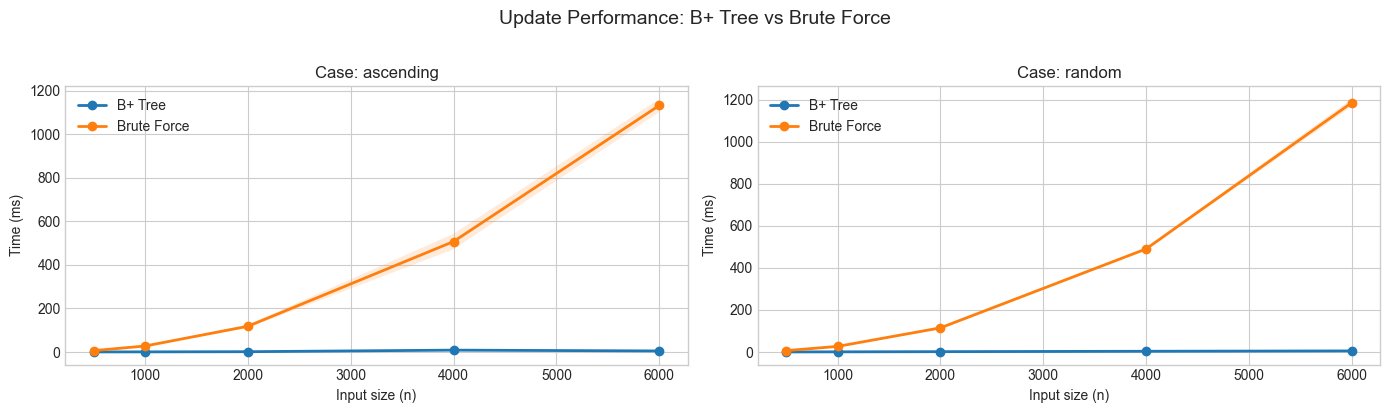


Speedup summary for Update:


structure,size,case,B+ Tree,Brute Force,speedup_(Brute/B+)
0,500,ascending,0.380,6.288,16.555
1,500,random,0.337,6.698,19.884
2,1000,ascending,0.602,27.541,45.765
3,1000,random,0.736,26.648,36.221
4,2000,ascending,1.418,118.291,83.421
5,2000,random,1.652,114.882,69.554
6,4000,ascending,8.593,507.584,59.067
7,4000,random,3.478,490.490,141.017
8,6000,ascending,4.845,1132.606,233.750
9,6000,random,5.153,1186.392,230.242


In [5]:
update_df = benchmark_update()
display(update_df.head(4))
plot_operation_grid(update_df, "Update Performance: B+ Tree vs Brute Force")
show_speedup_table(update_df, "Update")

## 5) Range Query Analysis

Range widths:
- narrow
- medium
- wide

Expected trend: B+ Tree should benefit strongly for selective ranges due to ordered leaf links and logarithmic seek to start point.

,operation,structure,case,size,time_ms_mean,time_ms_std
0,range_query,B+ Tree,medium,500,1.166733,0.338048
1,range_query,B+ Tree,narrow,500,0.478967,0.227720
2,range_query,B+ Tree,wide,500,25.725833,36.856857
3,range_query,Brute Force,medium,500,7.138633,0.628270
4,range_query,Brute Force,narrow,500,7.305133,1.203796
5,range_query,Brute Force,wide,500,8.672300,0.212462


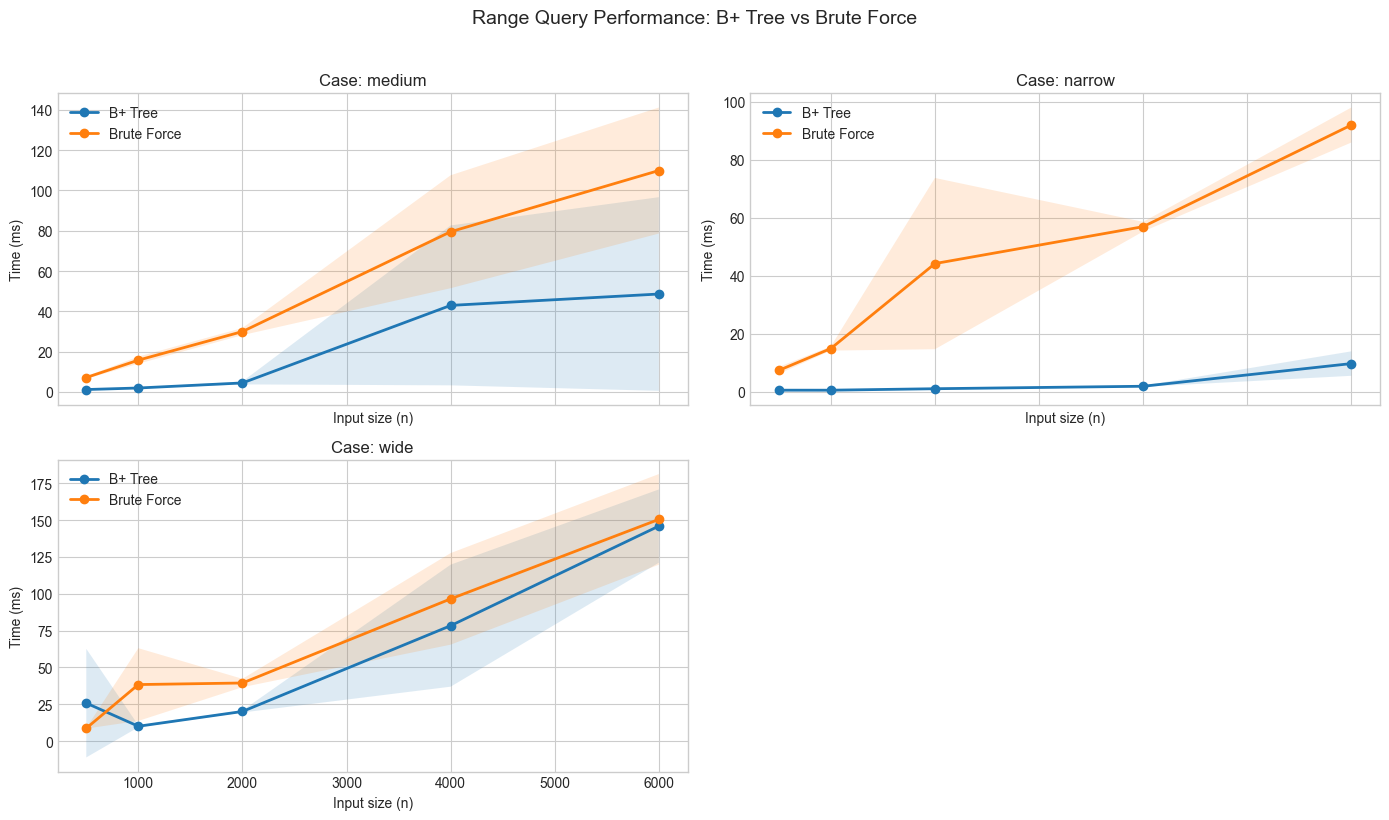


Speedup summary for Range Query:


structure,size,case,B+ Tree,Brute Force,speedup_(Brute/B+)
0,500,medium,1.167,7.139,6.118
1,500,narrow,0.479,7.305,15.252
2,500,wide,25.726,8.672,0.337
3,1000,medium,1.935,15.758,8.145
4,1000,narrow,0.474,14.846,31.289
5,1000,wide,10.015,38.324,3.827
6,2000,medium,4.440,29.959,6.748
7,2000,narrow,0.983,44.131,44.882
8,2000,wide,20.058,39.389,1.964
9,4000,medium,42.948,79.525,1.852


In [6]:
range_df = benchmark_range_query()
display(range_df.head(6))
plot_operation_grid(range_df, "Range Query Performance: B+ Tree vs Brute Force")
show_speedup_table(range_df, "Range Query")

## 6) Random Mixed Workload Analysis

This simulates practical workloads with random mixes of insert/search/delete/update/range operations.

,operation,structure,case,size,time_ms_mean,time_ms_std
0,mixed_random,B+ Tree,mixed_ops,500,1.031867,0.050701
1,mixed_random,Brute Force,mixed_ops,500,8.889933,0.679465
2,mixed_random,B+ Tree,mixed_ops,1000,2.019400,0.096724
3,mixed_random,Brute Force,mixed_ops,1000,35.928433,1.060647
4,mixed_random,B+ Tree,mixed_ops,2000,4.725300,0.174883
5,mixed_random,Brute Force,mixed_ops,2000,149.551600,9.730016
6,mixed_random,B+ Tree,mixed_ops,4000,11.637833,1.627380
7,mixed_random,Brute Force,mixed_ops,4000,628.127900,32.744773
8,mixed_random,B+ Tree,mixed_ops,6000,17.443133,1.850252
9,mixed_random,Brute Force,mixed_ops,6000,1396.772767,47.948885


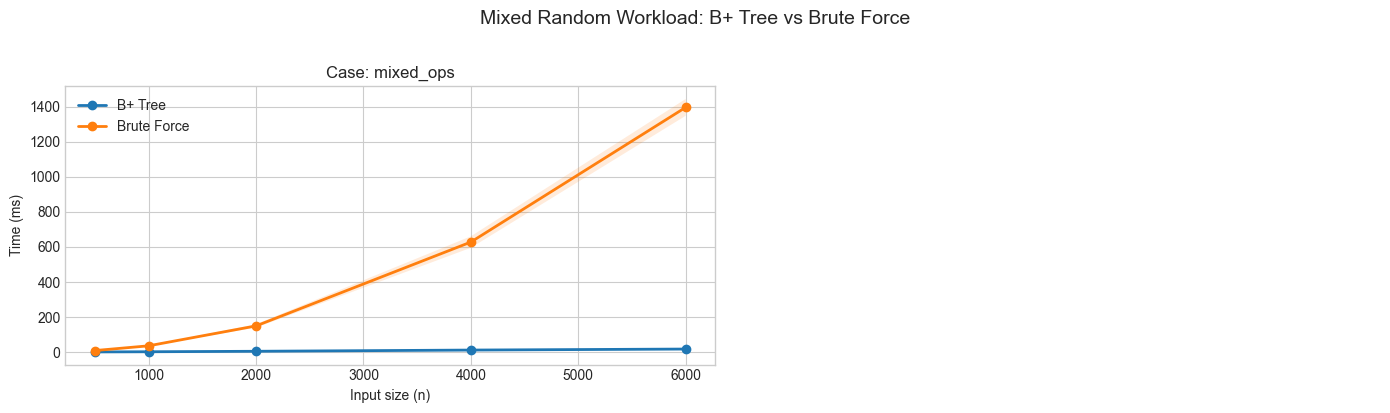


Speedup summary for Mixed Random Workload:


structure,size,case,B+ Tree,Brute Force,speedup_(Brute/B+)
0,500,mixed_ops,1.032,8.890,8.615
1,1000,mixed_ops,2.019,35.928,17.792
2,2000,mixed_ops,4.725,149.552,31.649
3,4000,mixed_ops,11.638,628.128,53.973
4,6000,mixed_ops,17.443,1396.773,80.076


In [7]:
mixed_df = benchmark_mixed_workload()
display(mixed_df)
plot_operation_grid(mixed_df, "Mixed Random Workload: B+ Tree vs Brute Force")
show_speedup_table(mixed_df, "Mixed Random Workload")

## 7) Memory Usage Analysis

Peak memory is measured with `tracemalloc` while running representative operation batches.

,operation,structure,case,size,memory_kb
0,memory_peak,B+ Tree,delete,500,8.468750
1,memory_peak,B+ Tree,insert,500,161.179688
2,memory_peak,B+ Tree,range_query,500,0.281250
3,memory_peak,B+ Tree,search,500,0.046875
4,memory_peak,Brute Force,delete,500,4.429688
5,memory_peak,Brute Force,insert,500,266.560547
6,memory_peak,Brute Force,range_query,500,0.281250
7,memory_peak,Brute Force,search,500,0.093750


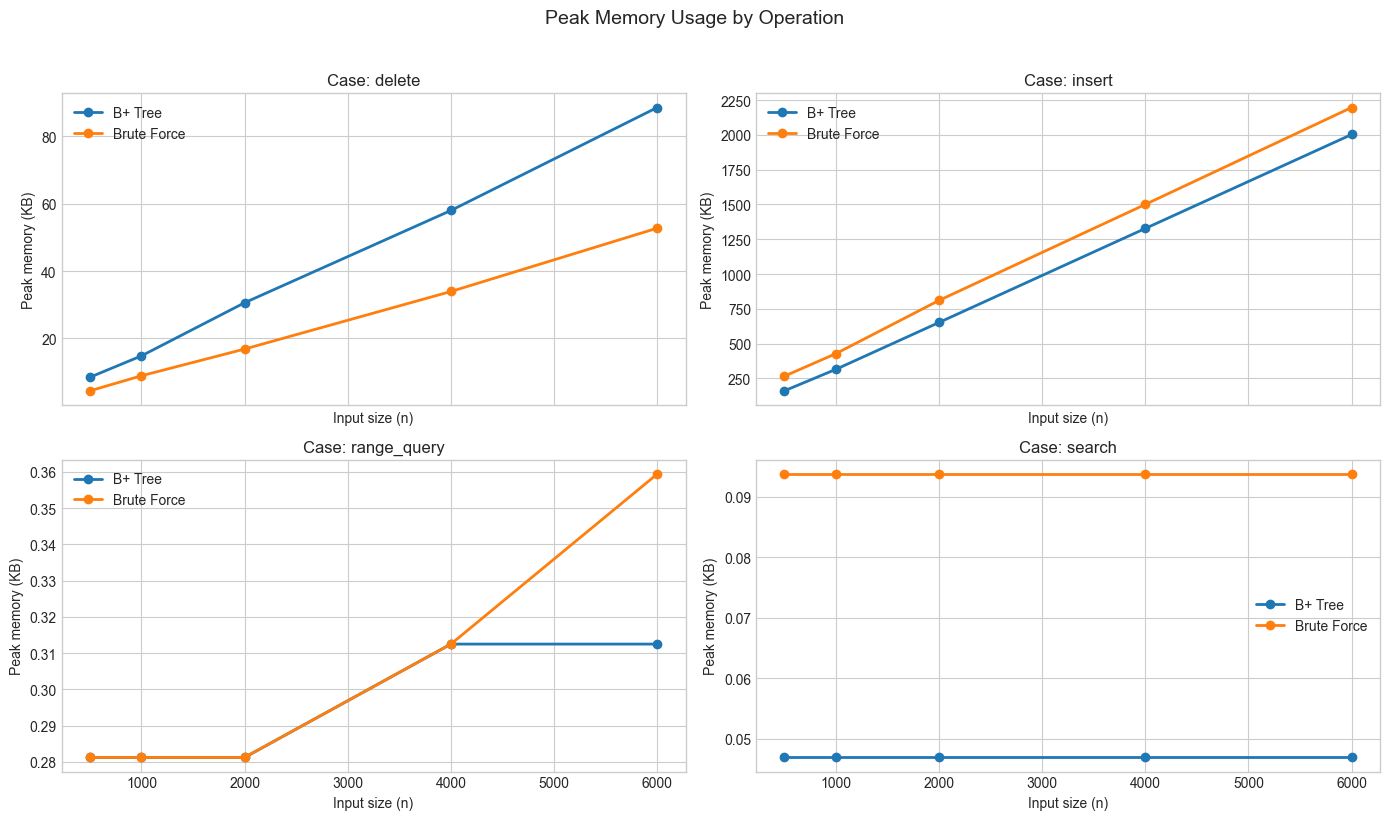

In [8]:
memory_df = benchmark_memory()
display(memory_df.head(8))
plot_operation_grid(memory_df, "Peak Memory Usage by Operation", y_col="memory_kb", y_label="Peak memory (KB)")

## 8) Automated Benchmarking

The figure below compares average time across operations (averaged across special cases) for each input size.

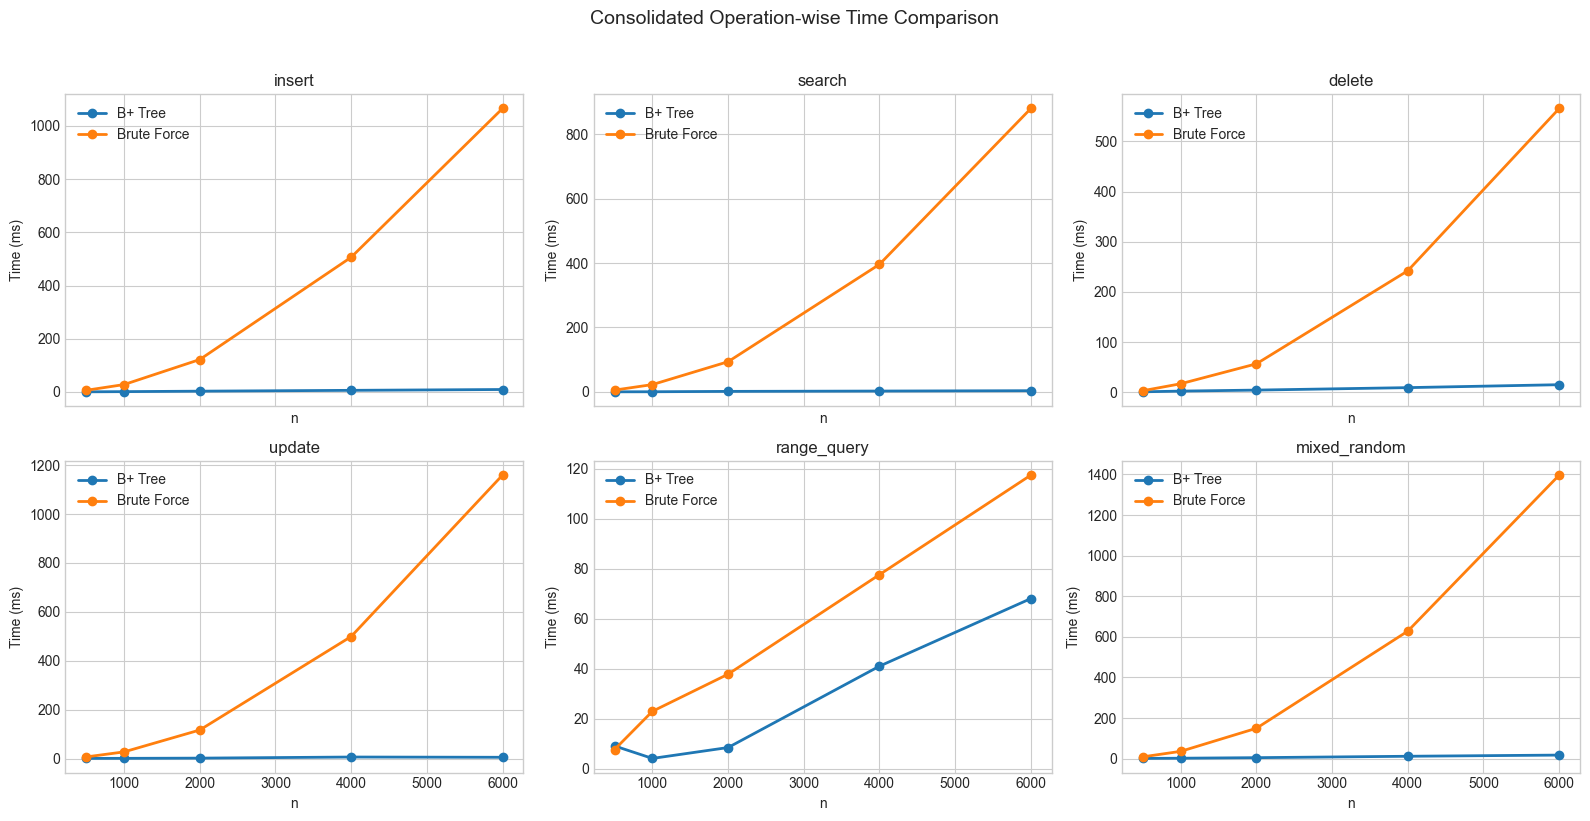

,operation,structure,time_ms_mean
0,delete,B+ Tree,6.288047
1,delete,Brute Force,176.911093
2,insert,B+ Tree,4.041367
3,insert,Brute Force,345.479842
4,mixed_random,B+ Tree,7.371507
5,mixed_random,Brute Force,443.854127
6,range_query,B+ Tree,26.168293
7,range_query,Brute Force,52.711918
8,search,B+ Tree,1.730029
9,search,Brute Force,279.457327


In [9]:
all_time_df = pd.concat([insert_df, search_df, delete_df, update_df, range_df, mixed_df], ignore_index=True)
ops = ["insert", "search", "delete", "update", "range_query", "mixed_random"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
axes = axes.reshape(-1)

for i, op in enumerate(ops):
    ax = axes[i]
    sub = all_time_df[all_time_df["operation"] == op]
    summary = sub.groupby(["size", "structure"], as_index=False)["time_ms_mean"].mean()
    for structure_name in summary["structure"].unique():
        part = summary[summary["structure"] == structure_name].sort_values("size")
        ax.plot(part["size"], part["time_ms_mean"], marker="o", linewidth=2, label=structure_name)
    ax.set_title(op)
    ax.set_xlabel("n")
    ax.set_ylabel("Time (ms)")
    ax.legend()

plt.suptitle("Consolidated Operation-wise Time Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

summary_table = all_time_df.groupby(["operation", "structure"], as_index=False)["time_ms_mean"].mean()
display(summary_table.sort_values(["operation", "time_ms_mean"]))

## 9) Visualization (Graphviz)

This section visualizes a B+ tree with Graphviz to demonstrate:
- **Tree Structure**: hierarchy of internal and leaf nodes.
- **Node Relationships**: parent-child connections from internal nodes to children.
- **Leaf Node Linkage**: dashed links across leaves to represent sequential access (linked-list behavior).

Color legend used by the tree renderer:
- Gray nodes: internal nodes
- Blue nodes: leaf nodes
- Blue dashed arrows: leaf-to-leaf linkage

**Input order:** 10, 30, 25, 80, 90, 100, 15, 18, 20, 60, 110, 120

### Step 1: insert 10

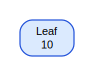

### Step 2: insert 30

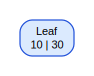

### Step 3: insert 25

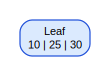

### Step 4: insert 80

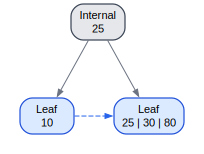

### Step 5: insert 90

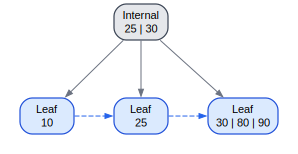

### Step 6: insert 100

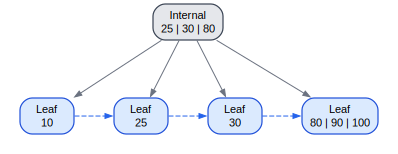

### Step 7: insert 15

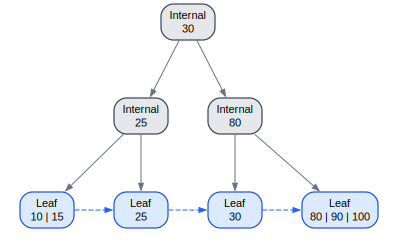

### Step 8: insert 18

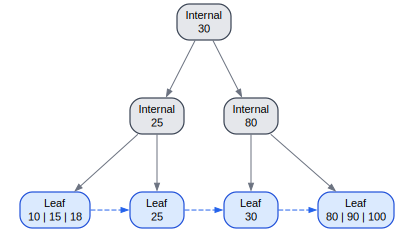

### Step 9: insert 20

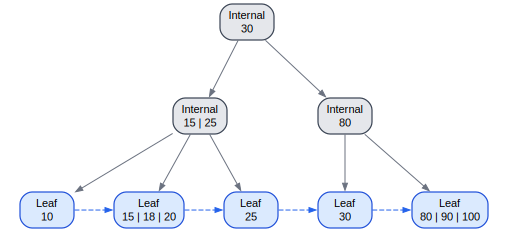

### Step 10: insert 60

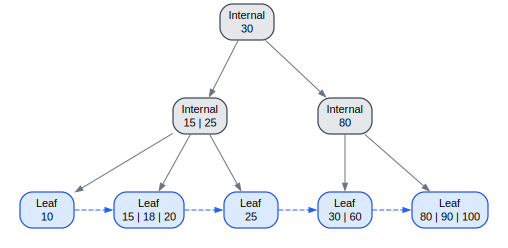

### Step 11: insert 110

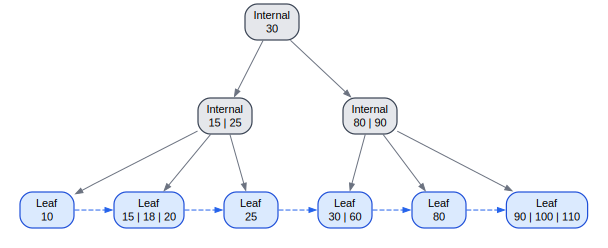

### Step 12: insert 120

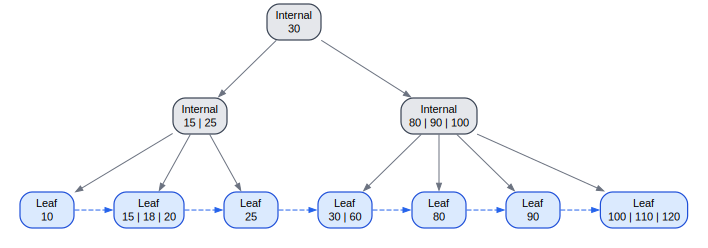

In [3]:
import importlib
import bplustree
from IPython.display import SVG, Markdown, display

importlib.reload(bplustree)
BPlusTree = bplustree.BPlusTree

example_keys = [10, 30, 25, 80, 90, 100, 15, 18, 20, 60, 110, 120]
tree = BPlusTree(order=4)

display(Markdown("**Input order:** " + ", ".join(map(str, example_keys))))

for step, key in enumerate(example_keys, start=1):
    tree.insert(key, {"student_id": key})
    display(Markdown(f"### Step {step}: insert {key}"))

    dot = tree.visualize_tree()
    svg_data = dot.pipe(format="svg").decode("utf-8")
    display(SVG(svg_data))

## 10) Conclusion

This project compared a B+ Tree-based DBMS against a brute-force baseline across insertion, search, deletion, update, range query, mixed workload, and memory benchmarks.

### Key findings
- B+ Tree generally scales better for lookup-heavy operations as input size increases, consistent with logarithmic search behavior.
- Range queries benefit from ordered leaf traversal, where B+ Tree avoids full scans in many cases.
- Brute force remains simple and can be competitive for very small datasets, but performance degrades as data grows.
- Memory trends show a trade-off: B+ Tree may incur higher structural overhead in some operations while providing stronger time efficiency.

### Challenges encountered
- Ensuring fair benchmarking across diverse input patterns (random, ascending, descending, clustered) required careful scenario design.
- Measuring memory is sensitive to runtime allocation behavior, so peak values can vary by operation sequence.
- Graphviz visualization required layout tuning to clearly represent hierarchy and leaf-linkage without rendering issues.

### Potential future improvements
- Add disk-aware page simulation to better model real DBMS behavior beyond in-memory structures.
- Introduce bulk-loading for B+ Tree construction to improve initial build performance.
- Extend concurrency support with locking/latching for multi-user workloads.
- Add more workload models (read-heavy, write-heavy, skewed access) and statistical confidence intervals for benchmarks.
- Compare with additional indexing structures (e.g., hash index, AVL/Red-Black tree) for broader evaluation.